# 01 Data Audit

Inspect raw annotation files, class balance, duplicates, and sentiment-bearing symbols before training.

In [36]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_utils import build_paths, discover_raw_files, merge_annotation_files, build_label_audit

paths = build_paths()
raw_files = discover_raw_files(paths.raw_dir)
raw_files

[PosixPath('/content/Sentiment_Analysis/data/raw/Copy of Facebook_Comment_Annotation - Perpetual.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_Comment_Annotation - Alfred.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_Comment_Annotation - Fitina.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_Comment_Annotation - Perpetual.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_Comment_Annotation - Rahema.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_Comment_Annotation - Thando.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_Comment_Annotation - Viwongo.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_comments - Lutha.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_comments - phiti.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_comments - rahe.csv'),
 PosixPath('/content/Sentiment_Analysis/data/raw/Facebook_comments - viwo.csv'),
 PosixPa

In [37]:
EXPECTED_COLUMNS = {"id", "text", "sentiment_label", "include"}
def load_annotation_file(file_path: Path) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df = df.rename(
        columns={
            "Unnamed: 0": "id",
            "topic-label": "topic_label",
            "sentiment-label": "sentiment_label",
            "Include": "include",
        }
    )
    missing = EXPECTED_COLUMNS - set(df.columns)
    if missing:
        missing_cols = ", ".join(sorted(missing))
        raise ValueError(f"{file_path.name} is missing required columns: {missing_cols}")
    df = df.copy()
    df["source_file"] = file_path.name
    return df

In [38]:
dfs = [load_annotation_file(f) for f in raw_files]


In [34]:
columns = [df.columns for df in dfs]
columns

[Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'sentiment_label', 'include', 'notes', 'id',
        'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
        'notes', 'source_file'],
       dtype='object'),
 Index(['id', 'text', 'topic_label', 'sentiment_label', '

In [40]:
indices = [df.index for df in dfs]
indices

[RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=52, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=52, step=1),
 RangeIndex(start=0, stop=51, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=80, step=1),
 RangeIndex(start=0, stop=34, step=1),
 RangeIndex(start=0, stop=34, step=1),
 RangeIndex(start=0, stop=35, step=1),
 RangeIndex(start=0, stop=47, step=1),
 RangeIndex(start=0, stop=34, step=1),
 RangeIndex(start=0, stop=35, step=1),
 RangeIndex(start=0, stop=161, step=1),
 RangeIndex(start=0, stop=164, step=1),
 RangeIndex(start=0, stop=163, step=1),
 RangeIndex(start=0, s

In [41]:
dfs = [load_annotation_file(f) for f in raw_files]
pd.concat(dfs, ignore_index=True)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
0,330.0,Good movie,Economy,Positive,Low,No,no topic,Copy of Facebook_Comment_Annotation - Perpetua...
1,331.0,Salute,Economy,Positive,Low,No,too short,Copy of Facebook_Comment_Annotation - Perpetua...
2,332.0,Zamphamvu kwambiri,Economy,positive,Medium,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...
3,333.0,The machine,Economy,Neutral,Low,No,unclear,Copy of Facebook_Comment_Annotation - Perpetua...
4,334.0,"Learning by doing approach, that's wonderful 🔥 🔥.",Economy,positive,High,Yes,teaching method,Copy of Facebook_Comment_Annotation - Perpetua...
...,...,...,...,...,...,...,...,...
2388,491.0,Mesa za police zo zimakaswa ma deal konko 😂😂😂,economy,negative,high,yes,NaN,sentiment spreadsheet - viwongo.csv
2389,492.0,Sitisowa a police koma tikusowa mafuta,economy,negative,high,yes,NaN,sentiment spreadsheet - viwongo.csv
2390,493.0,Hahaha izi si solution nkhani nkuti azipezeka ...,economy,negative,high,yes,NaN,sentiment spreadsheet - viwongo.csv
2391,494.0,Kukubwelaku muzamva asilikari apangidwa deploy...,economy,positive,high,yes,NaN,sentiment spreadsheet - viwongo.csv


In [42]:
merged = merge_annotation_files(raw_files)
audit = build_label_audit(merged)
merged.head()

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
0,330.0,Good movie,Economy,Positive,Low,No,no topic,Copy of Facebook_Comment_Annotation - Perpetua...
1,331.0,Salute,Economy,Positive,Low,No,too short,Copy of Facebook_Comment_Annotation - Perpetua...
2,332.0,Zamphamvu kwambiri,Economy,positive,Medium,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...
3,333.0,The machine,Economy,Neutral,Low,No,unclear,Copy of Facebook_Comment_Annotation - Perpetua...
4,334.0,"Learning by doing approach, that's wonderful 🔥 🔥.",Economy,positive,High,Yes,teaching method,Copy of Facebook_Comment_Annotation - Perpetua...


In [ ]:
audit.columns

Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
       'notes', 'source_file', 'sentiment_label_normalized',
       'include_normalized', 'text_missing', 'text_length_chars',
       'token_count_whitespace', 'is_short_comment', 'is_duplicate_text',
       'exclude_reason'],
      dtype='object')

In [ ]:
merged[merged["text"] == "Mbambande 🔥"]

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
493,98.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv
553,161.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv
816,184.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv
826,195.0,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv


In [ ]:
audit[['source_file', 'sentiment_label', 'sentiment_label_normalized', 'include', 'exclude_reason']].head(10)

,source_file,sentiment_label,sentiment_label_normalized,include,exclude_reason
0,Copy of Facebook_Comment_Annotation - Perpetua...,Positive,positive,No,include_not_yes
1,Copy of Facebook_Comment_Annotation - Perpetua...,Positive,positive,No,include_not_yes
2,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,Yes,
3,Copy of Facebook_Comment_Annotation - Perpetua...,Neutral,neutral,No,include_not_yes
4,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,Yes,
5,Copy of Facebook_Comment_Annotation - Perpetua...,Neutral,neutral,Yes,
6,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,Yes,
7,Copy of Facebook_Comment_Annotation - Perpetua...,Neutral,neutral,Yes,
8,Copy of Facebook_Comment_Annotation - Perpetua...,positive,positive,No,include_not_yes
9,Copy of Facebook_Comment_Annotation - Perpetua...,negative,negative,Yes,


In [ ]:
audit['sentiment_label_normalized'].value_counts(dropna=False)

sentiment_label_normalized
negative    1234
neutral      585
positive     520
None          54
Name: count, dtype: int64

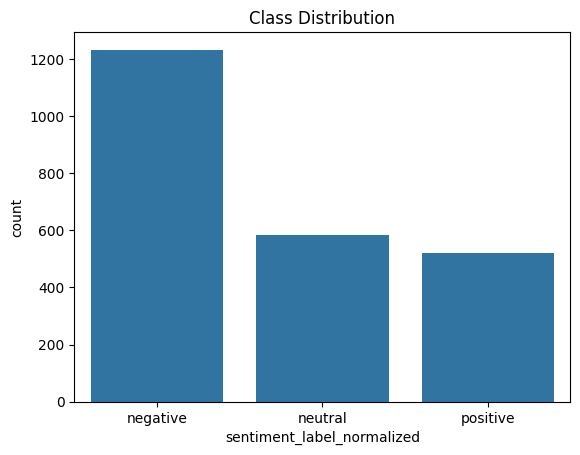

In [ ]:
sns.countplot(data=audit, x='sentiment_label_normalized', order=['negative', 'neutral', 'positive'])
plt.title('Class Distribution')
plt.show()

In [ ]:
audit['text_length_chars'].describe()

count    2393.000000
mean       63.631843
std        93.597960
min         0.000000
25%        22.000000
50%        42.000000
75%        73.000000
max      1980.000000
Name: text_length_chars, dtype: float64

In [ ]:
emoji_counts = merged['text'].fillna('').str.count(r'[\U00010000-\U0010ffff]')
emoji_counts.describe()

count    2393.000000
mean        0.737568
std         2.157005
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        60.000000
Name: text, dtype: float64

In [ ]:
audit[audit['exclude_reason'] != ''][['text', 'exclude_reason', 'source_file']].head(20)

,text,exclude_reason,source_file
0,Good movie,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
1,Salute,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
3,The machine,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
8,Keep it up mr🤗Home sweet home❤💫,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
13,Enafe ndiongepelekeza padzikoli,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
16,Kudya kulipo ......:,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
26,Mpulumutsi,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
29,Go ahead.,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
30,Dolo uyuyu,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
34,Nzeru zobambo transport,include_not_yes,Copy of Facebook_Comment_Annotation - Perpetua...
